<a href="https://colab.research.google.com/github/nth-ship-it/project-vuz/blob/%D0%BB%D0%B0%D0%B1%D0%B0-2/file_to_laba_N2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Новый раздел

Файл Wind.xlsx успешно прочитан.
Размерность ряда скорости ветра: (720,)


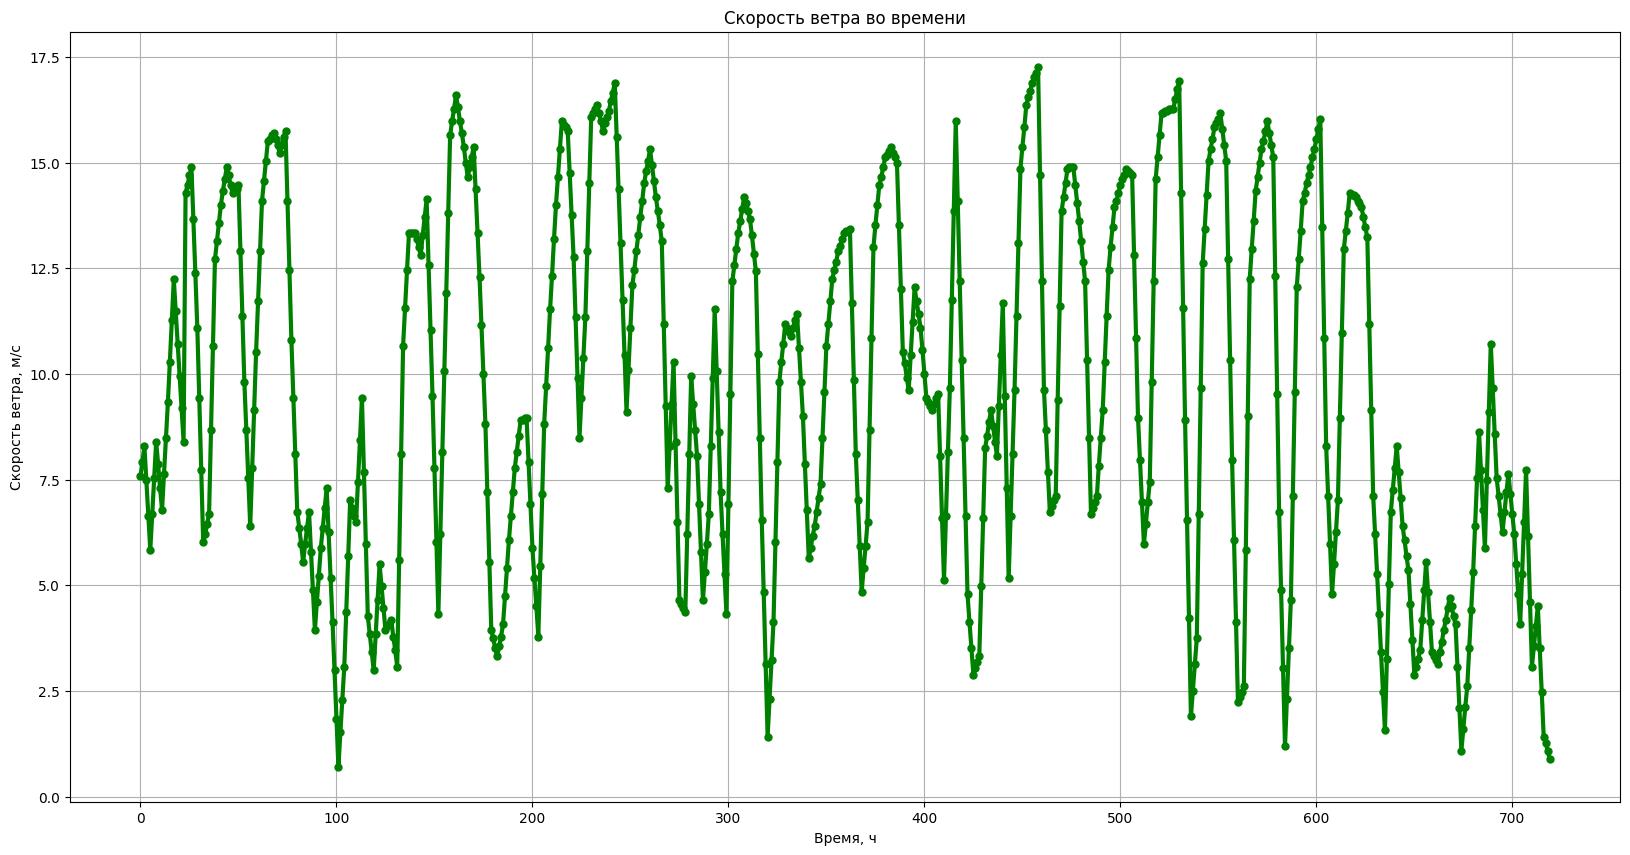

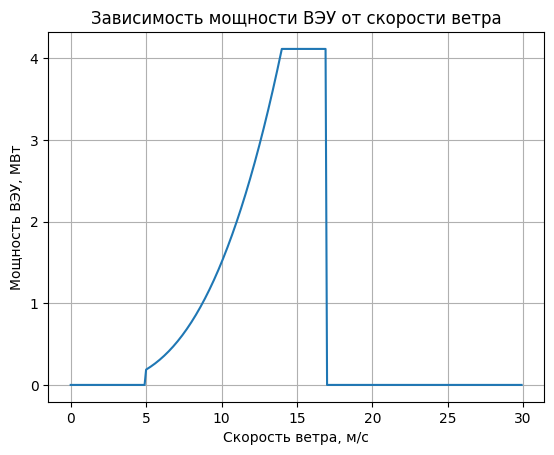

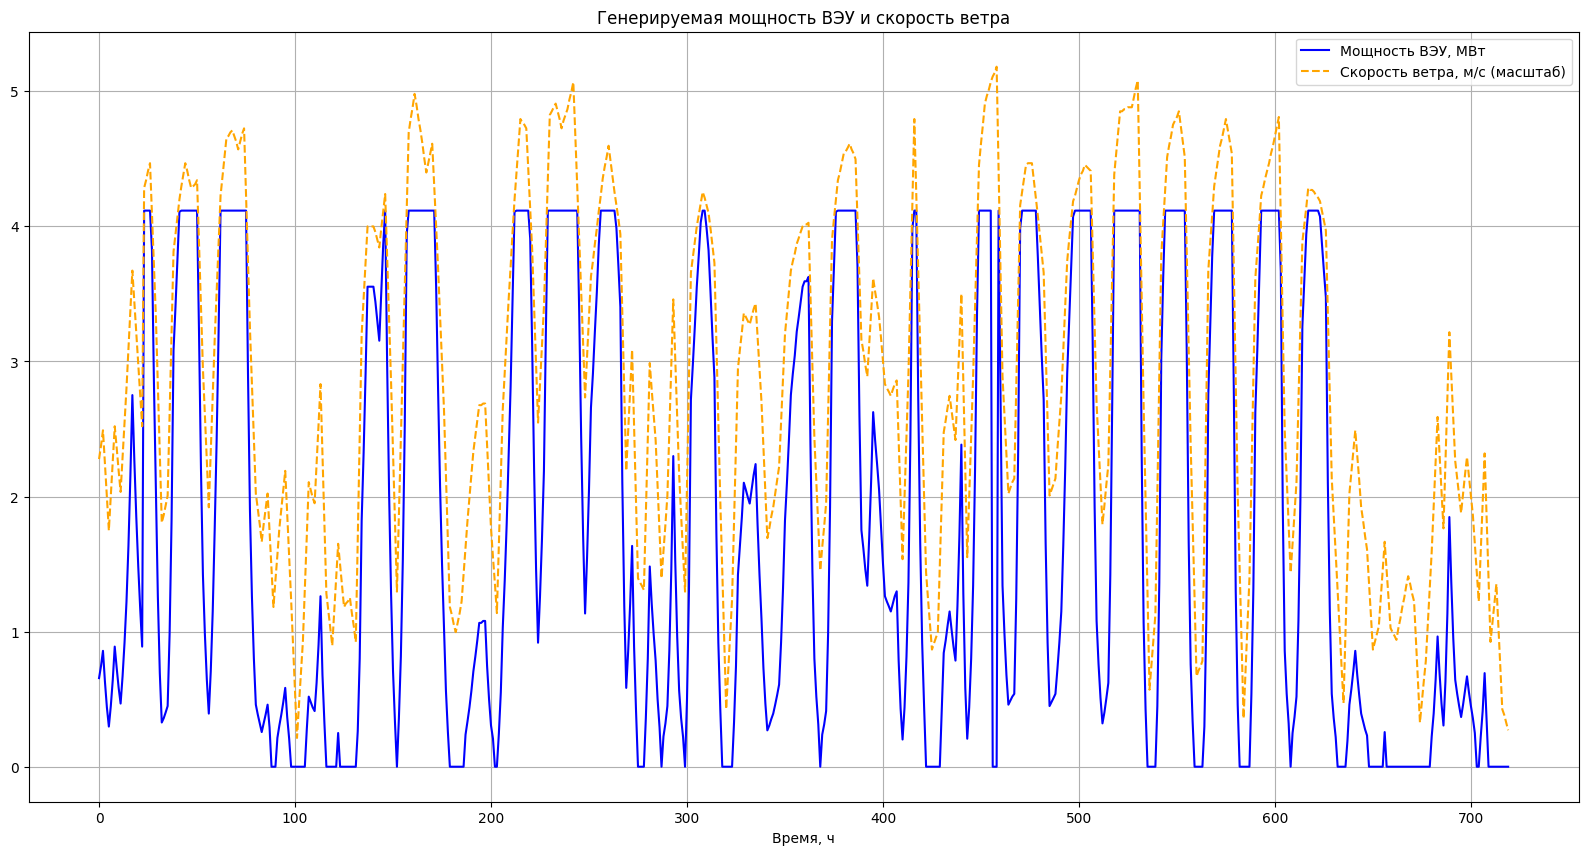


--- Статистические показатели ---
Скорость ветра (м/с):
count    720.000000
mean       9.708681
std        4.271513
min        0.710000
25%        6.260000
50%        9.465000
75%       13.710000
max       17.270000
dtype: float64

Генерируемая мощность (МВт):
count    720.000000
mean       1.841991
std        1.627407
min        0.000000
25%        0.359225
50%        1.261849
75%        3.823344
max        4.116000
dtype: float64


In [3]:
# -*- coding: utf-8 -*-
"""
Анализ данных ветра для варианта 2.
Используется файл Wind.xlsx.
"""

# 1. Подключение нужных для работы библиотек
import pandas as pd     # для чтения и записи табличных файлов
import numpy as np      # для математической обработки данных
import matplotlib.pyplot as plt # для построения графиков

# 2. Получение и чтение Excel файла с данными о ветре

url_wind_data = "https://drive.google.com/uc?export=download&id=1AqQZKW8l7Ks5vfe5q9VjEuJMb5JHVcj_"
try:
    # чтение данных из Excel файла
    # предполагаем, что в файле нет заголовков столбцов
    input_df_wind = pd.read_excel(url_wind_data, header=None)
    print("Файл Wind.xlsx успешно прочитан.")
except Exception as e:
    print(f"Ошибка при чтении файла Wind.xlsx: {e}")
    # Если чтение не удалось, прерываем выполнение или используем заглушку
    input_df_wind = None # Устанавливаем в None, чтобы избежать ошибок дальше

if input_df_wind is not None:
    # 3. Извлечение временного ряда скорости ветра
    wind_speed = input_df_wind.iloc[:, 2].values
    print(f"Размерность ряда скорости ветра: {wind_speed.shape}")

    # 4. Визуализация скорости ветра
    fig, ax = plt.subplots(figsize=(20, 10))
    ax.plot(wind_speed, linewidth=3, markersize=5, marker='o', color='green')
    ax.grid(True)
    ax.set_xlabel('Время, ч')
    ax.set_ylabel('Скорость ветра, м/с')
    ax.set_title('Скорость ветра во времени')
    plt.show()

    # 5. Определение функции зависимости мощности ВЭУ от скорости ветра
    # Используем функцию из Кода 2 как пример
    def wind_speed_to_power(speed):
        min_speed = 5      # Минимальная скорость для начала выработки
        max_speed = 14     # Максимальная скорость, при которой выработка не растет
        critical_speed = 17 # Скорость, при которой ВЭУ выключается

        # Инициализируем мощность нулем
        power = np.zeros_like(speed, dtype=float)

        # Определяем участки для расчета мощности
        # Скорость в рабочем диапазоне
        working_range = np.logical_and(speed >= min_speed, speed <= max_speed)
        # Скорость выше максимальной, но ниже критической (выработка на пике)
        peak_range = np.logical_and(speed > max_speed, speed < critical_speed)
        # Скорость ниже минимальной или выше критической (выработка равна нулю)

        # На рабочем участке мощность пропорциональна кубу скорости
        # Используем np.where для безопасного применения:
        power = np.where(working_range, 0.0015 * (speed ** 3), power)
        # При скорости выше max_speed, но ниже critical_speed, мощность равна мощности при max_speed
        # Из кода 2, похоже, что там не было ограничено ростом до critical_speed,
        # а подразумевалось, что при >max_speed мощность остается на уровне max_speed.
        # Перепишем с учетом этой логики, аналогичной коду 2:
        speed_clamped = np.clip(speed, a_min=min_speed, a_max=max_speed)
        power_clamped = np.where(speed < min_speed, 0, 0.0015 * (speed_clamped ** 3))
        # И обнуляем, если скорость выше критической
        power_clamped = np.where(speed >= critical_speed, 0, power_clamped)

        return power_clamped

    # Построение графика зависимости выработки от скорости ветра (как в Коде 2)
    x_wind = np.arange(0, 30, 0.1)
    fig_power_curve, ax_power_curve = plt.subplots()
    ax_power_curve.plot(x_wind, wind_speed_to_power(x_wind))
    ax_power_curve.grid(True)
    ax_power_curve.set_xlabel('Скорость ветра, м/с')
    ax_power_curve.set_ylabel('Мощность ВЭУ, МВт')
    ax_power_curve.set_title('Зависимость мощности ВЭУ от скорости ветра')
    plt.show()

    # 6. Расчет и визуализация генерируемой мощности ВЭУ
    generated_power = wind_speed_to_power(wind_speed)

    fig, ax = plt.subplots(figsize=(20, 10))
    ax.plot(generated_power, label='Мощность ВЭУ, МВт', color='blue')
    # Для наглядности можно также отобразить график скорости ветра, масштабированный
    ax.plot(wind_speed * 0.3, label='Скорость ветра, м/с (масштаб)', color='orange', linestyle='--') # Масштабировано для лучшего сравнения

    ax.grid(True)
    ax.set_xlabel('Время, ч')
    ax.legend()
    ax.set_title('Генерируемая мощность ВЭУ и скорость ветра')
    plt.show()

    # Дополнительно: Базовые статистические показатели для скорости ветра и мощности
    print("\n--- Статистические показатели ---")
    print(f"Скорость ветра (м/с):\n{pd.Series(wind_speed).describe()}")
    print(f"\nГенерируемая мощность (МВт):\n{pd.Series(generated_power).describe()}")

else:
    print("Не удалось продолжить выполнение из-за ошибки загрузки данных.")